In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('aramco_stock.csv')

# فهم الهيكل
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())
print(df.head())

(1164, 7)
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
              Open         High          Low        Close    Adj Close  \
count  1164.000000  1164.000000  1164.000000  1164.000000  1164.000000   
mean     30.502389    30.685119    30.314931    30.505042    28.200972   
std       2.769039     2.801027     2.715085     2.756249     3.361246   
min      22.314049    23.388430    22.314049    22.975206    19.394417   
25%      28.836777    28.925619    28.680785    28.818180    25.978118   
50%      29.628099    29.793388    29.504131    29.669420    27.945249   
75%      32.349998    32.560226    32.200001    32.400002    31.083448   
max      38.636364    39.409088    38.363636    38.636364    35.543354   

             Volume  
count  1.164000e+03  


In [5]:
# تحويل التاريخ
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# تحقق من duplicates
print(f"Duplicates: {df.duplicated().sum()}")

# تحقق من nulls مرة ثانية بعد التحويل
print(df.isnull().sum())

Duplicates: 0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [10]:
# المتوسطات المتحركة
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# العائد اليومي
df['Daily_Return'] = df['Close'].pct_change() * 100

# النطاق اليومي
df['Daily_Range'] = df['High'] - df['Low']

# الشمعة (صاعدة أم هابطة)
df['Candle'] = df.apply(lambda x: 'Bullish' if x['Close'] > x['Open'] else 'Bearish', axis=1)

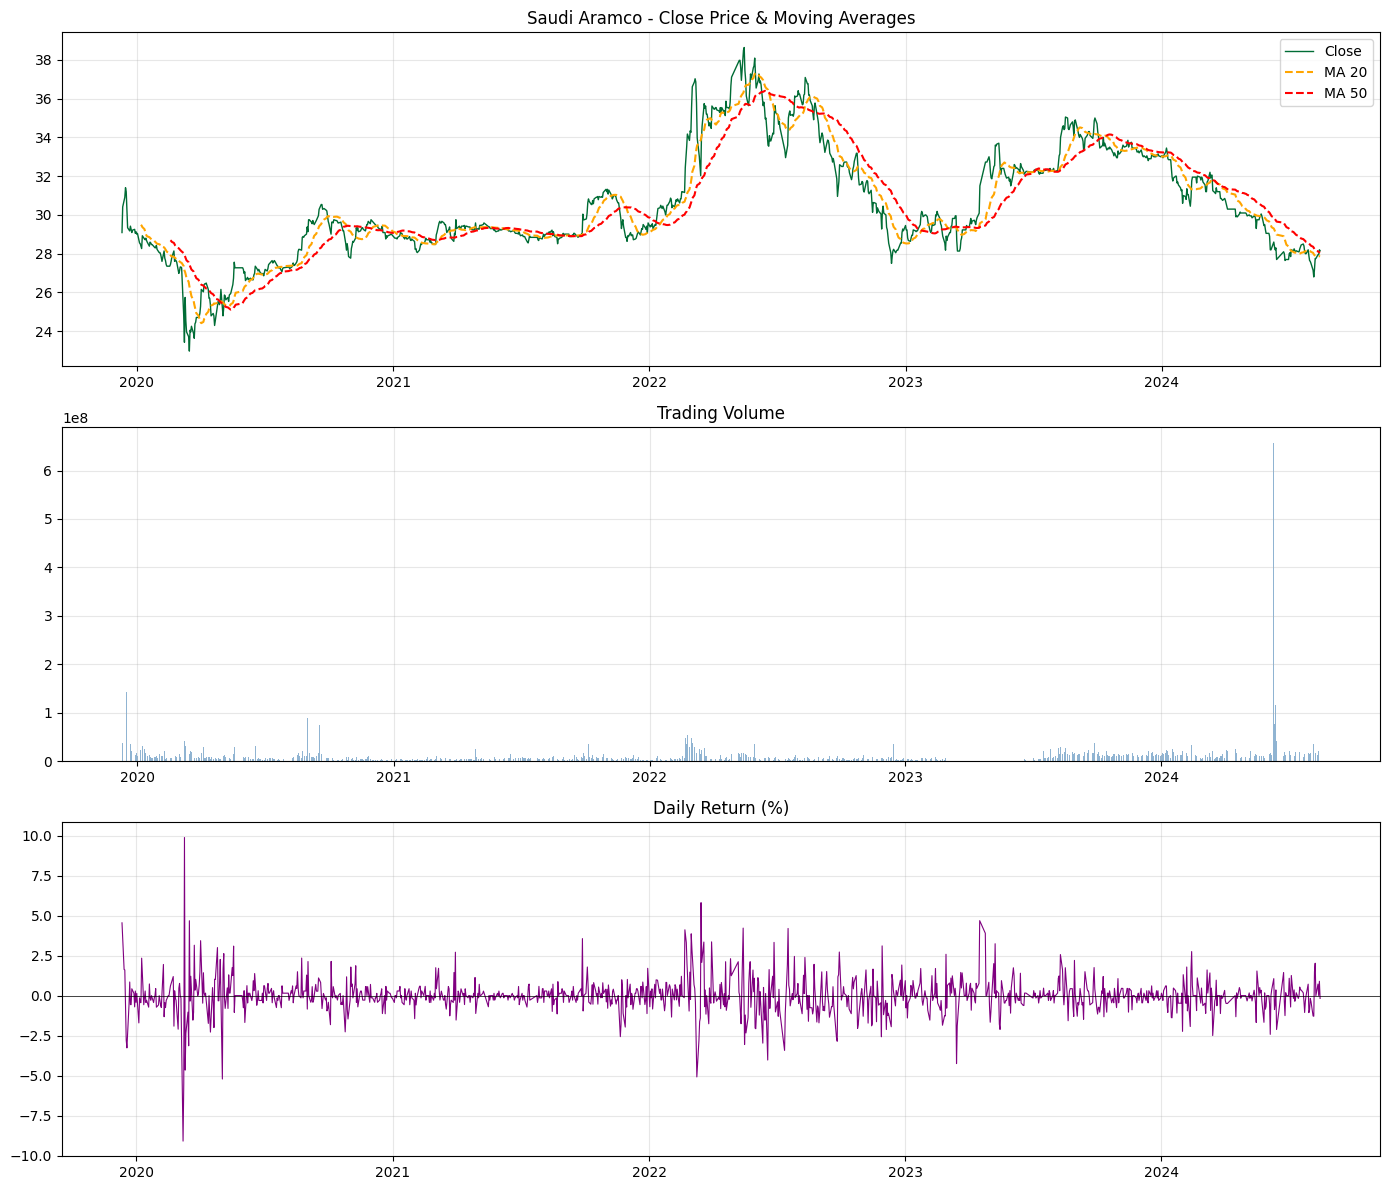

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. سعر الإغلاق + المتوسطات
axes[0].plot(df['Date'], df['Close'], label='Close', linewidth=1, color='#006C35')
axes[0].plot(df['Date'], df['MA_20'], label='MA 20', linestyle='--', color='orange')
axes[0].plot(df['Date'], df['MA_50'], label='MA 50', linestyle='--', color='red')
axes[0].set_title('Saudi Aramco - Close Price & Moving Averages')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. حجم التداول
axes[1].bar(df['Date'], df['Volume'], color='steelblue', alpha=0.6)
axes[1].set_title('Trading Volume')
axes[1].grid(True, alpha=0.3)

# 3. العائد اليومي
axes[2].plot(df['Date'], df['Daily_Return'], color='purple', linewidth=0.8)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('Daily Return (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aramco_analysis.png', dpi=150)
plt.show()

In [39]:
print("=== Key Statistics ===")
print(f"Date Range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total Trading Days: {len(df)}")
print(f"Highest Close: {df['Close'].max():.2f} SAR on {df.loc[df['Close'].idxmax(), 'Date'].date()}")
print(f"Lowest Close:  {df['Close'].min():.2f} SAR on {df.loc[df['Close'].idxmin(), 'Date'].date()}")
print(f"Average Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"Volatility (Std): {df['Daily_Return'].std():.4f}%")
print(f"Bullish Days: {(df['Candle']=='Bullish').sum()} | Bearish Days: {(df['Candle']=='Bearish').sum()}")

# حفظ ملف نظيف للـ Tableau
df.to_csv('aramco_cleaned.csv', index=False)
print("\naramco_cleaned.csv saved ✓")




=== Key Statistics ===
Date Range: 2019-12-11 → 2024-08-14
Total Trading Days: 1164
Highest Close: 38.64 SAR on 2022-05-16
Lowest Close:  22.98 SAR on 2020-03-16
Average Daily Return: 0.0034%
Volatility (Std): 1.1146%
Bullish Days: 508 | Bearish Days: 656

aramco_cleaned.csv saved ✓
